# A1 — Corpus Exploration (fill this)
Explore your scanned corpus: page/word counts, scan quality, script and font variety.

# EDA — Book 2 Corpus (`data/raw/bk2`)
Explores: page/word counts, scan quality, script and font variety.

In [15]:
import os
import re
import subprocess
import shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (10, 4)

## 1. Config & paths

In [16]:
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

CORPUS_DIR = REPO_ROOT / "data" / "raw" / "bk2"
assert CORPUS_DIR.exists(), f"Corpus dir not found: {CORPUS_DIR}"

# Resolve tesseract the same way the pipeline does: configured path -> PATH -> userspace env
def resolve_tesseract() -> tuple[str, str]:
    """Returns (tesseract_binary, tessdata_dir)."""
    env_prefix = Path(
        os.environ.get("TESSERACT_ENV_PREFIX", Path.home() / ".local" / "share" / "tesseract-env")
    )
    candidates = [
        env_prefix / "bin" / "tesseract",
        env_prefix / "Library" / "bin" / "tesseract.exe",
    ]
    tessdata_candidates = [
        env_prefix / "share" / "tessdata",
        env_prefix / "Library" / "share" / "tessdata",
    ]
    for c in candidates:
        if c.exists():
            tessdata = next((t for t in tessdata_candidates if t.exists()), "")
            return str(c), str(tessdata)
    which = shutil.which("tesseract")
    if which:
        return which, ""
    raise RuntimeError("tesseract not found — check TESSERACT_ENV_PREFIX or PATH.")


TESSERACT_CMD, TESSDATA_DIR = resolve_tesseract()
LANG = "ben+eng"
print(f"tesseract: {TESSERACT_CMD}")
print(f"tessdata:  {TESSDATA_DIR or '(default)'}")

tesseract: /root/.local/share/tesseract-env/bin/tesseract
tessdata:  /root/.local/share/tesseract-env/share/tessdata


In [17]:
def run_tesseract(image_path: Path, *extra_args: str) -> subprocess.CompletedProcess:
    cmd = [TESSERACT_CMD, str(image_path), "stdout", "-l", LANG]
    if TESSDATA_DIR:
        cmd.extend(["--tessdata-dir", TESSDATA_DIR])
    cmd.extend(extra_args)
    return subprocess.run(cmd, capture_output=True, text=True, encoding="utf-8", errors="replace")


# quick sanity check
_sanity_files = sorted(CORPUS_DIR.glob("*.png"))
print(f"Found {len(_sanity_files)} PNG pages in {CORPUS_DIR}")
assert _sanity_files, "No PNGs found — check the corpus path."

Found 445 PNG pages in /kaggle/working/doc-agent-G14/data/raw/bk2


## 2. Inventory — file sizes, image dimensions, DPI

In [18]:
def image_metadata(path: Path) -> dict:
    with Image.open(path) as img:
        width, height = img.size
        dpi = img.info.get("dpi", (None, None))
        mode = img.mode
    return {
        "file": path.name,
        "width_px": width,
        "height_px": height,
        "aspect_ratio": round(width / height, 3) if height else None,
        "dpi_x": dpi[0],
        "dpi_y": dpi[1],
        "mode": mode,
        "filesize_kb": round(path.stat().st_size / 1024, 1),
    }


pages = sorted(CORPUS_DIR.glob("*.png"))
inv_df = pd.DataFrame([image_metadata(p) for p in pages]).sort_values("file").reset_index(drop=True)
inv_df.head()

,file,width_px,height_px,aspect_ratio,dpi_x,dpi_y,mode,filesize_kb
0,10689.1338_0005.png,1508,2324,0.649,None,None,L,579.0
1,10689.1338_0006.png,1508,2324,0.649,None,None,L,396.9
2,10689.1338_0007.png,1508,2324,0.649,None,None,L,695.1
3,10689.1338_0008.png,1508,2324,0.649,None,None,L,812.7
4,10689.1338_0009.png,1508,2324,0.649,None,None,L,626.3


Total pages: 445
       width_px  height_px  filesize_kb
count     445.0      445.0   445.000000
mean     1508.0     2324.0   617.767640
std         0.0        0.0    84.698792
min      1508.0     2324.0   282.700000
25%      1508.0     2324.0   555.400000
50%      1508.0     2324.0   613.500000
75%      1508.0     2324.0   680.000000
max      1508.0     2324.0   839.200000

No DPI metadata embedded in these PNGs (common — scanners often omit it).


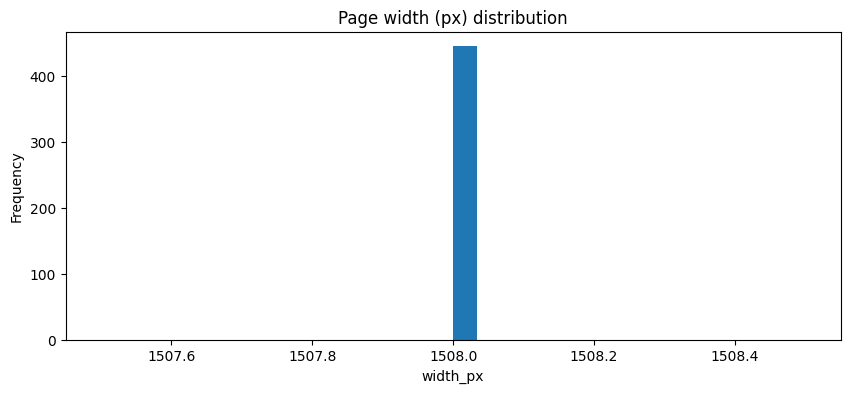

In [19]:
print(f"Total pages: {len(inv_df)}")
print(inv_df[["width_px", "height_px", "filesize_kb"]].describe())

if inv_df["dpi_x"].notna().any():
    low_dpi = inv_df[inv_df["dpi_x"] < 300]
    print(f"\nPages with DPI metadata < 300: {len(low_dpi)} / {len(inv_df)}")
else:
    print("\nNo DPI metadata embedded in these PNGs (common — scanners often omit it).")

inv_df["width_px"].plot(kind="hist", bins=30, title="Page width (px) distribution")
plt.xlabel("width_px")
plt.show()

## 3. Word / page counts via Tesseract

In [20]:
import csv
import io
from tqdm import tqdm


def page_word_stats(path: Path) -> dict:
    result = run_tesseract(path, "tsv")
    if result.returncode != 0:
        return {"file": path.name, "word_count": 0, "mean_conf": np.nan, "error": result.stderr.strip()}

    words, confs = 0, []
    for row in csv.DictReader(io.StringIO(result.stdout), delimiter="\t"):
        if row.get("level") == "5" and row.get("text", "").strip():
            words += 1
            try:
                conf = float(row["conf"])
                if conf >= 0:  # tesseract uses -1 for n/a
                    confs.append(conf)
            except (KeyError, ValueError):
                pass
    return {
        "file": path.name,
        "word_count": words,
        "mean_conf": round(np.mean(confs), 1) if confs else np.nan,
        "error": None,
    }


word_stats = [page_word_stats(p) for p in tqdm(pages)]
word_df = pd.DataFrame(word_stats)
inv_df = inv_df.merge(word_df, on="file", how="left")

failed = inv_df[inv_df["error"].notna()]
if len(failed):
    print(f"⚠️ {len(failed)} pages failed OCR entirely — inspect these first:")
    print(failed[["file", "error"]])

100%|██████████| 445/445 [20:04<00:00,  2.71s/it]


Total words across corpus: 80,901
Median words/page: 185
count    445.000000
mean     181.800000
std       60.168442
min        0.000000
25%      151.000000
50%      185.000000
75%      223.000000
max      314.000000
Name: word_count, dtype: float64


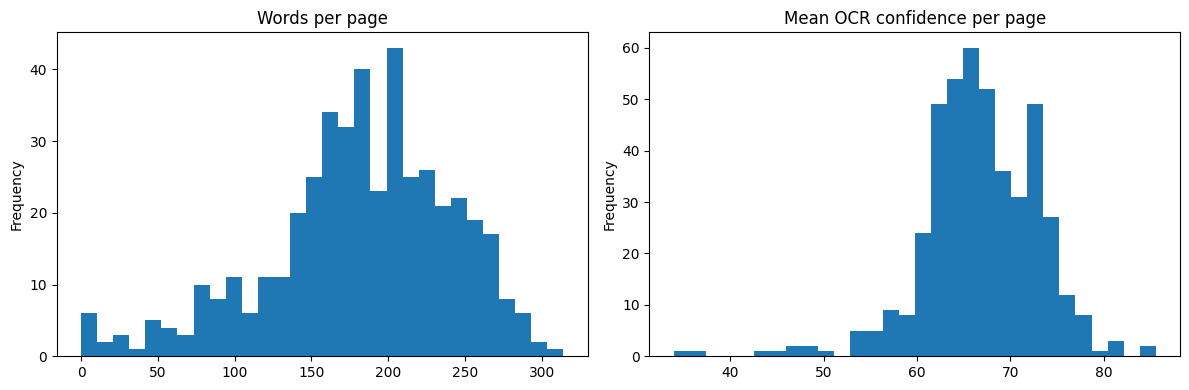


Bottom 5% by word count (22 pages) — check for blank/illustration/failed pages:
                    file  word_count  mean_conf
6    10689.1338_0011.png          21       49.0
7    10689.1338_0013.png           0        NaN
127  10689.1338_0137.png           8       62.7
147  10689.1338_0157.png          46       71.3
158  10689.1338_0168.png          61       75.2
193  10689.1338_0203.png          54       63.1
203  10689.1338_0213.png          25       62.3
232  10689.1338_0242.png          47       63.7
252  10689.1338_0262.png          56       65.4
255  10689.1338_0265.png           3       69.4
273  10689.1338_0283.png          16       71.9
275  10689.1338_0285.png          50       66.6
283  10689.1338_0293.png          46       63.3
306  10689.1338_0316.png           8       64.5
314  10689.1338_0324.png          41       68.7
327  10689.1338_0337.png          53       69.5
338  10689.1338_0348.png          20       85.6
361  10689.1338_0371.png           4       33.9
371  10

In [21]:
print(f"Total words across corpus: {inv_df['word_count'].sum():,}")
print(f"Median words/page: {inv_df['word_count'].median():.0f}")
print(inv_df["word_count"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
inv_df["word_count"].plot(kind="hist", bins=30, ax=axes[0], title="Words per page")
inv_df["mean_conf"].plot(kind="hist", bins=30, ax=axes[1], title="Mean OCR confidence per page")
plt.tight_layout()
plt.show()

# flag likely-blank or OCR-failure pages
sparse = inv_df[inv_df["word_count"] < inv_df["word_count"].quantile(0.05)]
print(f"\nBottom 5% by word count ({len(sparse)} pages) — check for blank/illustration/failed pages:")
print(sparse[["file", "word_count", "mean_conf"]])

## 4. Scan quality
Blur (Laplacian variance — lower = blurrier), brightness, and contrast, computed
directly with numpy (no extra CV dependency).

100%|██████████| 445/445 [01:14<00:00,  6.01it/s]


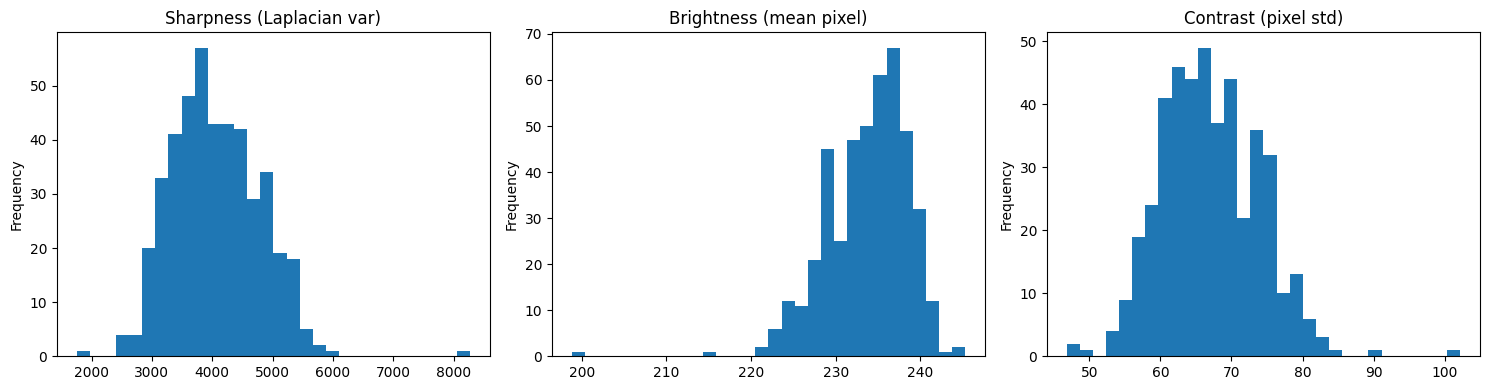

In [22]:
LAPLACIAN_KERNEL = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float64)


def laplacian_variance(gray: np.ndarray) -> float:
    """2D convolution with a Laplacian kernel; variance of the result ~ 'sharpness'."""
    padded = np.pad(gray, 1, mode="edge")
    out = np.zeros_like(gray, dtype=np.float64)
    kh, kw = LAPLACIAN_KERNEL.shape
    for i in range(kh):
        for j in range(kw):
            if LAPLACIAN_KERNEL[i, j] == 0:
                continue
            out += LAPLACIAN_KERNEL[i, j] * padded[i : i + gray.shape[0], j : j + gray.shape[1]]
    return float(out.var())


def quality_metrics(path: Path) -> dict:
    with Image.open(path) as img:
        gray = np.asarray(img.convert("L"), dtype=np.float64)
    # downsample large pages for speed — blur/contrast are stable under this
    if gray.shape[0] > 1500:
        step = gray.shape[0] // 1500
        gray = gray[::step, ::step]
    return {
        "file": path.name,
        "sharpness": round(laplacian_variance(gray), 1),
        "brightness_mean": round(float(gray.mean()), 1),
        "contrast_std": round(float(gray.std()), 1),
    }


quality_df = pd.DataFrame([quality_metrics(p) for p in tqdm(pages)])
inv_df = inv_df.merge(quality_df, on="file", how="left")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
inv_df["sharpness"].plot(kind="hist", bins=30, ax=axes[0], title="Sharpness (Laplacian var)")
inv_df["brightness_mean"].plot(kind="hist", bins=30, ax=axes[1], title="Brightness (mean pixel)")
inv_df["contrast_std"].plot(kind="hist", bins=30, ax=axes[2], title="Contrast (pixel std)")
plt.tight_layout()
plt.show()

In [23]:
# Cross-check: low sharpness/contrast pages vs low OCR confidence — validates the metrics
# actually track something the OCR engine struggles with, not just noise.
quality_corr = inv_df[["sharpness", "brightness_mean", "contrast_std", "mean_conf"]].corr()
print(quality_corr["mean_conf"].sort_values())

worst_scans = inv_df.nsmallest(5, "sharpness")[["file", "sharpness", "contrast_std", "mean_conf"]]
print("\n5 blurriest pages:")
print(worst_scans)

brightness_mean   -0.237499
contrast_std       0.266453
sharpness          0.323246
mean_conf          1.000000
Name: mean_conf, dtype: float64

5 blurriest pages:
                    file  sharpness  contrast_std  mean_conf
440  10689.1338_0450.png     1751.1          46.8       65.4
91   10689.1338_0099.png     2450.0          57.8       65.8
1    10689.1338_0006.png     2459.4          47.9       47.4
209  10689.1338_0219.png     2476.8          55.8       59.7
92   10689.1338_0101.png     2516.6          59.1       69.8


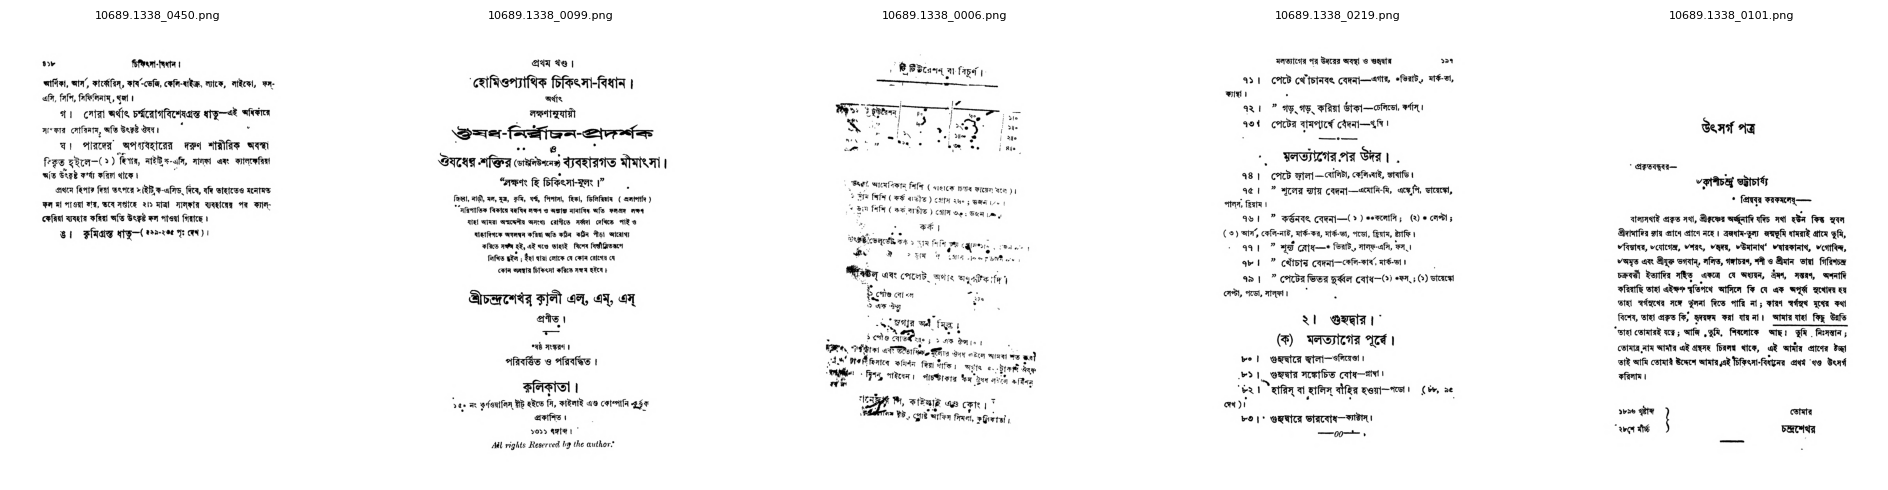

In [24]:
# Visually spot-check the worst few
fig, axes = plt.subplots(1, len(worst_scans), figsize=(4 * len(worst_scans), 5))
if len(worst_scans) == 1:
    axes = [axes]
for ax, fname in zip(axes, worst_scans["file"]):
    with Image.open(CORPUS_DIR / fname) as img:
        ax.imshow(img.convert("L"), cmap="gray")
    ax.set_title(fname, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Script variety
Two independent signals:
1. Tesseract's own OSD (Orientation & Script Detection) — one dominant script guess/page.
2. Unicode-range classification of every recognized word — captures **code-switching**
   within a page (e.g. Bengali body text with Latin drug names/abbreviations), which OSD
   can't see since it only reports a single dominant script per page.

In [25]:
def detect_osd(path: Path) -> dict:
    result = run_tesseract(path, "--psm", "0")
    if result.returncode != 0:
        return {"file": path.name, "osd_script": None, "osd_script_conf": np.nan, "osd_orientation": np.nan}
    text = result.stdout
    script = re.search(r"Script:\s*(\S+)", text)
    script_conf = re.search(r"Script confidence:\s*([\d.]+)", text)
    orientation = re.search(r"Orientation in degrees:\s*(-?\d+)", text)
    return {
        "file": path.name,
        "osd_script": script.group(1) if script else None,
        "osd_script_conf": float(script_conf.group(1)) if script_conf else np.nan,
        "osd_orientation": int(orientation.group(1)) if orientation else np.nan,
    }


osd_df = pd.DataFrame([detect_osd(p) for p in tqdm(pages)])
inv_df = inv_df.merge(osd_df, on="file", how="left")

print("OSD dominant-script counts:")
print(inv_df["osd_script"].value_counts(dropna=False))

rotated = inv_df[inv_df["osd_orientation"].fillna(0) != 0]
print(f"\nPages OSD thinks are rotated: {len(rotated)}")
if len(rotated):
    print(rotated[["file", "osd_orientation"]])

100%|██████████| 445/445 [00:58<00:00,  7.64it/s]

OSD dominant-script counts:
osd_script
None    445
Name: count, dtype: int64

Pages OSD thinks are rotated: 0


100%|██████████| 445/445 [19:54<00:00,  2.68s/it]

Corpus-wide word-script mix (%):
bengali        78.1
latin          13.0
digit           0.8
punct_other     8.1
dtype: float64


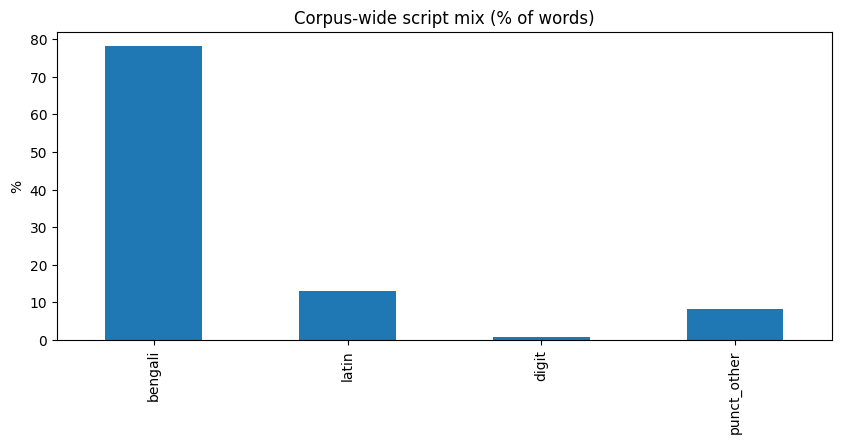

In [26]:
BENGALI_RANGE = (0x0980, 0x09FF)


def classify_char(ch: str) -> str:
    cp = ord(ch)
    if BENGALI_RANGE[0] <= cp <= BENGALI_RANGE[1]:
        return "bengali"
    if ch.isascii() and ch.isalpha():
        return "latin"
    if ch.isdigit():
        return "digit"
    if ch.isspace():
        return "space"
    return "punct_other"


def word_script_mix(path: Path) -> dict:
    result = run_tesseract(path, "tsv")
    counts = Counter()
    if result.returncode != 0:
        return {"file": path.name}
    for row in csv.DictReader(io.StringIO(result.stdout), delimiter="\t"):
        text = row.get("text", "")
        if row.get("level") != "5" or not text.strip():
            continue
        char_classes = Counter(classify_char(c) for c in text)
        # classify the whole word by its majority non-space class
        char_classes.pop("space", None)
        if not char_classes:
            continue
        dominant = char_classes.most_common(1)[0][0]
        counts[dominant] += 1
    counts["file"] = path.name
    return dict(counts)


script_mix_df = pd.DataFrame([word_script_mix(p) for p in tqdm(pages)]).fillna(0)
for col in ["bengali", "latin", "digit", "punct_other"]:
    if col not in script_mix_df.columns:
        script_mix_df[col] = 0

inv_df = inv_df.merge(script_mix_df, on="file", how="left")

# corpus-wide script mix
totals = inv_df[["bengali", "latin", "digit", "punct_other"]].sum()
totals_pct = (totals / totals.sum() * 100).round(1)
print("Corpus-wide word-script mix (%):")
print(totals_pct)

totals_pct.plot(kind="bar", title="Corpus-wide script mix (% of words)")
plt.ylabel("%")
plt.show()

In [27]:
# Pages with meaningful code-switching (both bengali and latin words present)
mixed = inv_df[(inv_df["bengali"] > 0) & (inv_df["latin"] > 0)]
print(f"Pages with both Bengali and Latin words: {len(mixed)} / {len(inv_df)}")
inv_df["latin_pct"] = (inv_df["latin"] / inv_df[["bengali", "latin", "digit", "punct_other"]].sum(axis=1) * 100).round(1)
inv_df.nlargest(5, "latin_pct")[["file", "bengali", "latin", "latin_pct"]]

Pages with both Bengali and Latin words: 442 / 445


,file,bengali,latin,latin_pct
3,10689.1338_0008.png,26.0,253.0,80.6
80,10689.1338_0087.png,36.0,99.0,68.8
4,10689.1338_0009.png,33.0,71.0,62.8
0,10689.1338_0005.png,34.0,66.0,56.9
5,10689.1338_0010.png,27.0,42.0,50.6


## 6. Font variety
Tesseract doesn't expose font family identification through the CLI/TSV path this
pipeline uses. As a proxy, word bounding-box **height** (a stand-in for font size) and
its within-page variance are used to flag pages with likely mixed fonts/sizes (e.g.
headings vs body vs footnotes). True font-family clustering would need a separate
vision model — noted as a follow-up, not attempted here.

100%|██████████| 445/445 [19:30<00:00,  2.63s/it]


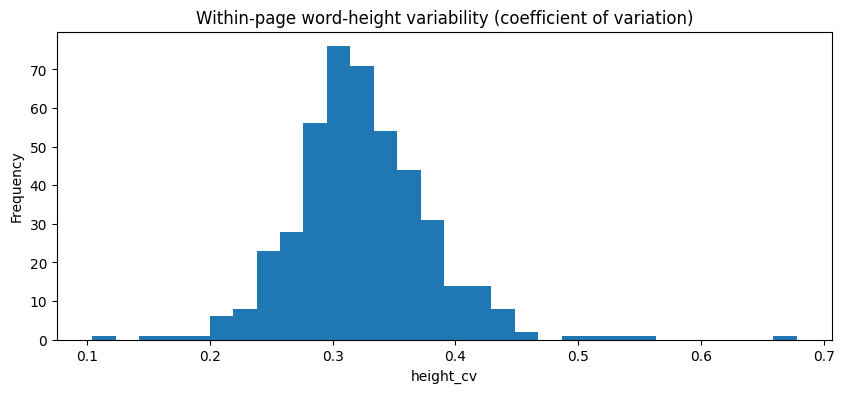

Pages with the most size variation (likely mixed heading/body/footnote fonts):
                  file  height_median  height_cv  n_size_clusters
2  10689.1338_0007.png           43.0      0.678               15
1  10689.1338_0006.png           39.5      0.557               25
0  10689.1338_0005.png           41.0      0.543               18
4  10689.1338_0009.png           36.0      0.518               11
5  10689.1338_0010.png           39.0      0.501               10


In [28]:
def word_heights(path: Path) -> dict:
    result = run_tesseract(path, "tsv")
    heights = []
    if result.returncode == 0:
        for row in csv.DictReader(io.StringIO(result.stdout), delimiter="\t"):
            if row.get("level") == "5" and row.get("text", "").strip():
                try:
                    heights.append(int(row["height"]))
                except (KeyError, ValueError):
                    pass
    if not heights:
        return {"file": path.name, "height_median": np.nan, "height_cv": np.nan, "n_size_clusters": 0}
    heights = np.array(heights)
    cv = heights.std() / heights.mean() if heights.mean() else 0
    # crude "distinct size cluster" count: round to nearest 2px, count unique bins with >=3 words
    bins = Counter(np.round(heights / 2) * 2)
    clusters = sum(1 for count in bins.values() if count >= 3)
    return {
        "file": path.name,
        "height_median": float(np.median(heights)),
        "height_cv": round(float(cv), 3),
        "n_size_clusters": clusters,
    }


height_df = pd.DataFrame([word_heights(p) for p in tqdm(pages)])
inv_df = inv_df.merge(height_df, on="file", how="left")

inv_df["height_cv"].plot(kind="hist", bins=30, title="Within-page word-height variability (coefficient of variation)")
plt.xlabel("height_cv")
plt.show()

print("Pages with the most size variation (likely mixed heading/body/footnote fonts):")
print(inv_df.nlargest(5, "height_cv")[["file", "height_median", "height_cv", "n_size_clusters"]])

## 7. Summary & export

In [29]:
summary = {
    "n_pages": len(inv_df),
    "total_words": int(inv_df["word_count"].sum()),
    "median_words_per_page": float(inv_df["word_count"].median()),
    "mean_ocr_confidence": float(inv_df["mean_conf"].mean()),
    "pages_below_p5_wordcount": int(len(sparse)),
    "median_sharpness": float(inv_df["sharpness"].median()),
    "pages_flagged_blurry_bottom5pct": int((inv_df["sharpness"] < inv_df["sharpness"].quantile(0.05)).sum()),
    "pct_words_bengali": float(totals_pct.get("bengali", 0)),
    "pct_words_latin": float(totals_pct.get("latin", 0)),
    "pages_with_code_switching": int(len(mixed)),
    "pages_rotated_per_osd": int(len(rotated)),
    "median_height_cv": float(inv_df["height_cv"].median()),
}
for k, v in summary.items():
    print(f"{k}: {v}")

n_pages: 445
total_words: 80901
median_words_per_page: 185.0
mean_ocr_confidence: 66.77927927927928
pages_below_p5_wordcount: 22
median_sharpness: 3983.9
pages_flagged_blurry_bottom5pct: 23
pct_words_bengali: 78.1
pct_words_latin: 13.0
pages_with_code_switching: 442
pages_rotated_per_osd: 0
median_height_cv: 0.3205
